In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import pandas as pd
import os
import ssl
from glob import glob
import random
import torchvision.transforms.functional as F
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

## Kiểm tra GPU

In [11]:
print("Có GPU không? :", torch.cuda.is_available())  # Phải trả về True
print("Phiên bản CUDA trong PyTorch:", torch.version.cuda)
print("Tên GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Không có GPU")

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng: {device}") # phải là: Đang sử dụng: cuda

Có GPU không? : True
Phiên bản CUDA trong PyTorch: 11.8
Tên GPU: GRID P40-24Q
Đang sử dụng: cuda


## Load dữ liệu

In [12]:
# Định nghĩa đường dẫn thư mục chứa dữ liệu
data_dir = "data/images"
train_data, valid_data, test_data = [], [], []
label_map = {}  # Mapping nhãn -> số

for label_idx, label in enumerate(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue
    
    # Lưu ánh xạ nhãn
    label_map[label] = label_idx
    
    # Lấy danh sách ảnh và sắp xếp để đảm bảo đúng thứ tự
    image_paths = sorted(glob(os.path.join(label_path, "*")))
    
    # Chia thành hai phần: loại ảnh 1 (2500 ảnh đầu) và loại ảnh 2 (2500 ảnh cuối)
    type1_images = image_paths[:2500]
    type2_images = image_paths[2500:]

    def split_data(image_list):
        """Chia dữ liệu theo tỷ lệ 90:5:5"""
        total = len(image_list)
        train_split = int(0.9 * total)
        valid_split = int(0.95 * total)

        return (
            [(p, label_idx) for p in image_list[:train_split]],  # Train
            [(p, label_idx) for p in image_list[train_split:valid_split]],  # Valid
            [(p, label_idx) for p in image_list[valid_split:]]  # Test
        )

    # Chia dữ liệu đều cho từng loại ảnh
    train_1, valid_1, test_1 = split_data(type1_images)
    train_2, valid_2, test_2 = split_data(type2_images)

    # Ghép hai phần lại với nhau
    train_data.extend(train_1 + train_2)
    valid_data.extend(valid_1 + valid_2)
    test_data.extend(test_1 + test_2)

## train

In [13]:
# Định nghĩa Dataset
class ImageDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Định nghĩa các phép biến đổi dữ liệu
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize ảnh về kích thước chuẩn
    transforms.ToTensor(), # Chuyển ảnh thành tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Chuẩn hóa theo ImageNet
])

# Tạo DataLoader
batch_size = 32 # số lượng mẫu được đưa vào mô hình trong 1 lần huấn luyện
train_loader = DataLoader(ImageDataset(train_data, transform), batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(ImageDataset(valid_data, transform), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(ImageDataset(test_data, transform), batch_size=batch_size, shuffle=False)

# Số lớp đầu ra
num_classes = len(label_map.keys())
print(num_classes)

4


In [14]:
# Kiểm tra số lượng mẫu mỗi tập
print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")

# Hiển thị một số đường dẫn ảnh từ mỗi tập (kiểm tra kết quả)
print("Sample train images:", train_data[:3])
print("Sample valid images:", valid_data[:3])
print("Sample test images:", test_data[:3])
print("labels: ", label_map)

Train: 18000, Valid: 1000, Test: 1000
Sample train images: [('data/images\\BENIGN\\0.png', 0), ('data/images\\BENIGN\\1.png', 0), ('data/images\\BENIGN\\10.png', 0)]
Sample valid images: [('data/images\\BENIGN\\3022.png', 0), ('data/images\\BENIGN\\3023.png', 0), ('data/images\\BENIGN\\3024.png', 0)]
Sample test images: [('data/images\\BENIGN\\3135.png', 0), ('data/images\\BENIGN\\3136.png', 0), ('data/images\\BENIGN\\3137.png', 0)]
labels:  {'BENIGN': 0, 'Group1': 1, 'Group2': 2, 'Syn': 3}


In [15]:
# Kiểm tra thiết bị (GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [16]:
# Sử dụng khi thuê GPU trên máy ảo để tải base model
ssl._create_default_https_context = ssl._create_unverified_context

In [17]:
# Load mô hình MobileNet đã pretrain
model = models.mobilenet_v2(pretrained=True)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(label_map.keys()))
model = model.to(device)

In [18]:
# Cấu hình loss và optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [19]:
# Cấu hình
batch_size = 32
epochs = 20

# Huấn luyện
train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []
best_valid_loss = float("inf")

def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    accuracy = 100 * correct / total
    return running_loss / len(loader), accuracy, all_labels, all_preds

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total
    valid_loss, valid_accuracy, _, _ = evaluate(model, valid_loader)
    
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accuracies.append(train_accuracy)
    valid_accuracies.append(valid_accuracy)
    
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, Valid Loss: {valid_loss:.4f}, Valid Accuracy: {valid_accuracy:.2f}%")
    
    # Lưu model tốt nhất
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "models/mobilenet_finetune.pth")
        print("Lưu model tốt nhất!")

Epoch [1/20], Train Loss: 0.0990, Train Accuracy: 97.30%, Valid Loss: 0.0859, Valid Accuracy: 96.20%
Lưu model tốt nhất!
Epoch [2/20], Train Loss: 0.0701, Train Accuracy: 98.01%, Valid Loss: 0.1370, Valid Accuracy: 94.80%
Epoch [3/20], Train Loss: 0.0631, Train Accuracy: 98.17%, Valid Loss: 0.1124, Valid Accuracy: 95.90%
Epoch [4/20], Train Loss: 0.0568, Train Accuracy: 98.32%, Valid Loss: 0.0902, Valid Accuracy: 95.90%
Epoch [5/20], Train Loss: 0.0577, Train Accuracy: 98.28%, Valid Loss: 0.0706, Valid Accuracy: 96.20%
Lưu model tốt nhất!
Epoch [6/20], Train Loss: 0.0594, Train Accuracy: 98.21%, Valid Loss: 0.0814, Valid Accuracy: 96.30%
Epoch [7/20], Train Loss: 0.0486, Train Accuracy: 98.41%, Valid Loss: 0.1045, Valid Accuracy: 95.80%
Epoch [8/20], Train Loss: 0.0560, Train Accuracy: 98.27%, Valid Loss: 0.0808, Valid Accuracy: 96.90%
Epoch [9/20], Train Loss: 0.0514, Train Accuracy: 98.36%, Valid Loss: 0.0722, Valid Accuracy: 96.40%
Epoch [10/20], Train Loss: 0.0455, Train Accuracy: 

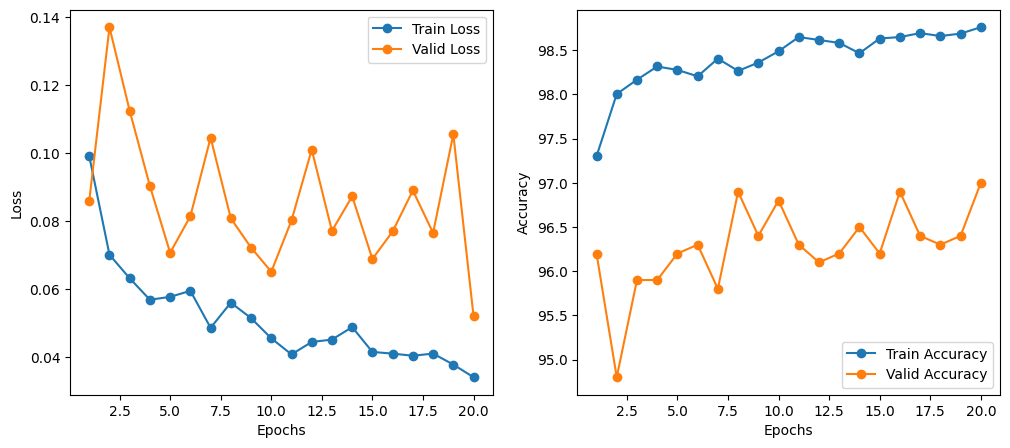

In [20]:
# Vẽ biểu đồ loss và accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, epochs+1), valid_losses, marker='o', label='Valid Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, marker='o', label='Train Accuracy')
plt.plot(range(1, epochs+1), valid_accuracies, marker='o', label='Valid Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Đánh giá

In [22]:
# Định nghĩa đường dẫn thư mục chứa dữ liệu
data_dir = "data/images"
train_data, valid_data, test_data = [], [], []
label_map = {}  # Mapping nhãn -> số

for label_idx, label in enumerate(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue
    
    # Lưu ánh xạ nhãn
    label_map[label] = label_idx
    
    # Lấy danh sách ảnh và sắp xếp để đảm bảo đúng thứ tự
    image_paths = sorted(glob(os.path.join(label_path, "*")))
    
    # Chia thành hai phần: loại ảnh 1 (2500 ảnh đầu) và loại ảnh 2 (2500 ảnh cuối)
    type1_images = image_paths[:2500]
    type2_images = image_paths[2500:]

    def split_data(image_list):
        """Chia dữ liệu theo tỷ lệ 90:5:5"""
        total = len(image_list)
        train_split = int(0.9 * total)
        valid_split = int(0.95 * total)

        return (
            [(p, label_idx) for p in image_list[:train_split]],  # Train
            [(p, label_idx) for p in image_list[train_split:valid_split]],  # Valid
            [(p, label_idx) for p in image_list[valid_split:]]  # Test
        )

    # Chia dữ liệu đều cho từng loại ảnh
    train_1, valid_1, test_1 = split_data(type1_images)
    train_2, valid_2, test_2 = split_data(type2_images)

    # Ghép hai phần lại với nhau
    train_data.extend(train_1 + train_2)
    valid_data.extend(valid_1 + valid_2)
    test_data.extend(test_1 + test_2)
    
# Kiểm tra số lượng mẫu mỗi tập
print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")

# Hiển thị một số đường dẫn ảnh từ mỗi tập (kiểm tra kết quả)
print("Sample train images:", train_data[:3])
print("Sample valid images:", valid_data[:3])
print("Sample test images:", test_data[:3])
print("labels: ", label_map)

# Định nghĩa Dataset
class ImageDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Định nghĩa các phép biến đổi dữ liệu
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize ảnh về kích thước chuẩn
    transforms.ToTensor(), # Chuyển ảnh thành tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Chuẩn hóa theo ImageNet
])

# Tạo DataLoader
batch_size = 32 # số lượng mẫu được đưa vào mô hình trong 1 lần huấn luyện
test_loader = DataLoader(ImageDataset(test_data, transform), batch_size=batch_size, shuffle=False)

# Số lớp đầu ra
num_classes = len(label_map.keys())
print(num_classes)

Train: 18000, Valid: 1000, Test: 1000
Sample train images: [('data/images\\BENIGN\\0.png', 0), ('data/images\\BENIGN\\1.png', 0), ('data/images\\BENIGN\\10.png', 0)]
Sample valid images: [('data/images\\BENIGN\\3022.png', 0), ('data/images\\BENIGN\\3023.png', 0), ('data/images\\BENIGN\\3024.png', 0)]
Sample test images: [('data/images\\BENIGN\\3135.png', 0), ('data/images\\BENIGN\\3136.png', 0), ('data/images\\BENIGN\\3137.png', 0)]
labels:  {'BENIGN': 0, 'Group1': 1, 'Group2': 2, 'Syn': 3}
4


In [23]:
# Kiểm tra thiết bị (GPU nếu có)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print("Using device:", device)

model = models.mobilenet_v2(pretrained=True)

# Định nghĩa lại lớp classifier giống lúc train
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, num_classes)

# Load trọng số đã train
model.load_state_dict(torch.load("models/mobilenet_finetune.pth", map_location=device))


Using device: cpu


<All keys matched successfully>

In [24]:
# Evaluate on test set
def evaluate_model(model, test_loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return y_true, y_pred

y_true, y_pred = evaluate_model(model, test_loader)

In [25]:
# Tính độ chính xác trên tập test
test_accuracy_1 = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy_1:.4f}")

Test Accuracy: 0.9690


In [26]:
# Tính các chỉ số đánh giá
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=label_map.keys()))

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.98      0.99       250
      Group1       0.92      0.99      0.95       250
      Group2       0.97      0.91      0.94       250
         Syn       1.00      0.99      0.99       250

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



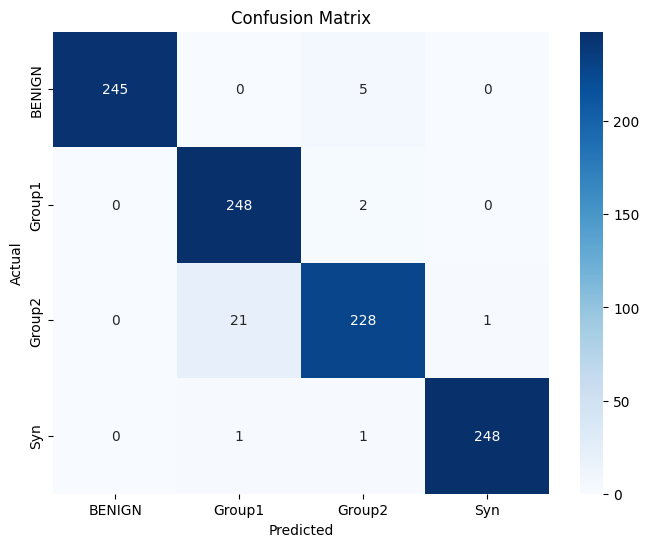

In [27]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


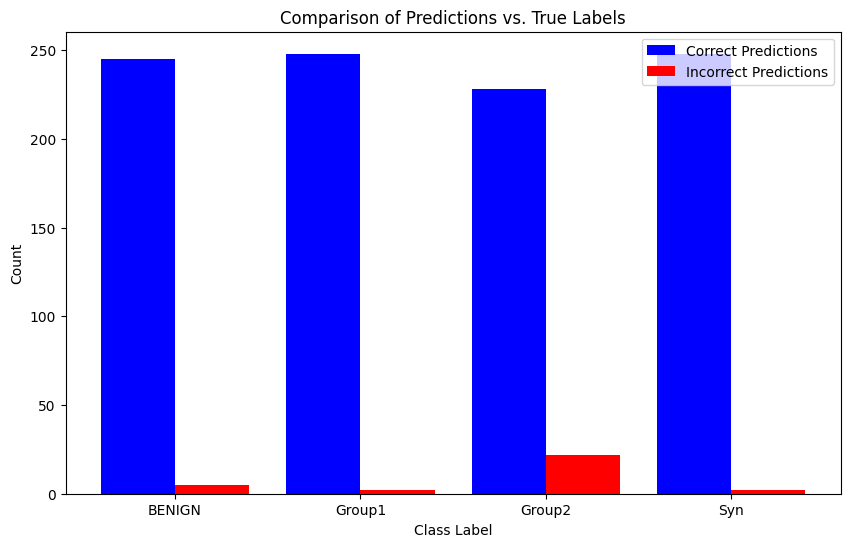

In [28]:
# Tạo DataFrame chứa nhãn thực tế và dự đoán
df = pd.DataFrame({"True Label": y_true, "Predicted Label": y_pred})

# Đếm số lượng dự đoán đúng và sai theo từng lớp
df["Correct"] = (df["True Label"] == df["Predicted Label"])  # True nếu dự đoán đúng

# Đếm số lượng đúng/sai theo từng lớp
correct_counts = df[df["Correct"]].groupby("True Label").size()
incorrect_counts = df[~df["Correct"]].groupby("True Label").size()

# Đảm bảo tất cả nhãn có trong bảng
correct_counts = correct_counts.reindex(range(num_classes), fill_value=0)
incorrect_counts = incorrect_counts.reindex(range(num_classes), fill_value=0)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.4
index = np.arange(num_classes)

plt.bar(index, correct_counts, bar_width, label="Correct Predictions", color="blue")
plt.bar(index + bar_width, incorrect_counts, bar_width, label="Incorrect Predictions", color="red")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Comparison of Predictions vs. True Labels")
plt.xticks(index + bar_width / 2, label_map.keys(), rotation=0)
plt.legend()
plt.show()

In [10]:
# Test individual images
def predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    print(f'Predicted label: {class_names[predicted.item()]}')


# Test individual images
def total_predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    return class_names[predicted.item()]

In [11]:
labels_list = list(label_map.keys())
print(labels_list)

# predict_image(model, "data/test/SYN/1.png", list(label_map.keys()))
# predict_image(model, "data/test/haa/rrr.png", list(label_map.keys()))

# predict_image(model, "data/cic_ddos_2019_images/Syn/4343.png", list(label_map.keys()))

# thống kê chi tiết tên nhãn dự đoán
for i in range(0, len(labels_list)):
    name_details_dict = {}

    for j in test_data:
        if j[1] == i:
            r = total_predict_image(model, f"{j[0]}", labels_list)
            if r in name_details_dict:
                name_details_dict[r] += 1
            else:
                name_details_dict[r] = 1

    print(f'Label: {labels_list[i]}', name_details_dict)



['BENIGN', 'Group1', 'Group2', 'Syn']
Label: BENIGN {'BENIGN': 250}
Label: Group1 {'Group1': 233, 'Group2': 17}
Label: Group2 {'Group2': 228, 'Group1': 20, 'BENIGN': 1, 'Syn': 1}
Label: Syn {'Syn': 246, 'BENIGN': 1, 'Group2': 3}
